<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/012_multi_agent_supervisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Um agente generalista ou vários agentes especializados?

**Área:** Agentic AI  
**Tipo de problema:** Delegation, routing, specialization e coordenação

### Pergunta de estudo

> Um sistema com supervisor e agentes especializados resolve tarefas compostas melhor do que um único agente com acesso a todas as ferramentas?

O Study 011 avaliou um único agente com ferramentas.

Neste estudo serão comparadas duas arquiteturas:

### Arquitetura A — Single Agent

```text
Usuário
   ↓
Agente generalista
   ↓
┌────────────────────────────────────┐
│ inventory │ pricing │ logistics    │
│ calculator │ conversion │ shipping │
└────────────────────────────────────┘
```

### Arquitetura B — Multi-Agent

```text
                       Usuário
                          ↓
                     Supervisor
                          ↓
          ┌───────────────┼───────────────┐
          ↓               ↓               ↓
   Inventory Agent   Pricing Agent   Logistics Agent
          ↓               ↓               ↓
   ferramentas        ferramentas      ferramentas
   especializadas     especializadas   especializadas
```

### Hipótese

Especialização pode:

- reduzir o espaço de decisão de cada agente;
- melhorar seleção de ferramentas;
- limitar acesso desnecessário;
- favorecer separação de responsabilidades.

Por outro lado, coordenação pode introduzir:

- mais inferências;
- handoffs;
- latência;
- redundância;
- propagação de erros.

### Métricas

#### Outcome
- Task Success Rate

#### Routing / Delegation
- Specialist Coverage
- Exact Specialist Match
- Redundant Delegations
- Handoffs

#### Tool execution
- Tool Coverage
- Tool Execution Success
- Tool Errors

#### Efficiency
- Steps
- Nested model calls
- Latency
- Coordination overhead

O objetivo não é provar que multi-agent é sempre melhor, mas identificar **quando a decomposição em agentes especializados ajuda e quando apenas adiciona complexidade**.


## 1. Configuração do ambiente

O estudo usa o mesmo modelo nas duas arquiteturas para reduzir variáveis de confusão.

- **Modelo:** Hermes 2 Pro Llama 3 8B
- **Quantização:** 4-bit
- **Execução recomendada:** GPU no Google Colab

O modelo será utilizado em três papéis:

1. single agent;
2. supervisor;
3. especialistas.

A diferença observada será principalmente arquitetural.


In [1]:
!pip -q install -U transformers accelerate bitsandbytes pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 44.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [2]:
import ast
import json
import math
import operator
import random
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from transformers.utils import get_json_schema

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "NousResearch/Hermes-2-Pro-Llama-3-8B"

MAX_SPECIALIST_STEPS = 6
MAX_SINGLE_AGENT_STEPS = 10
MAX_SUPERVISOR_STEPS = 8
MAX_NEW_TOKENS = 256

print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

if not torch.cuda.is_available():
    print(
        "ATENÇÃO: este notebook foi planejado "
        "para execução com GPU no Google Colab."
    )


PyTorch: 2.11.0+cu128
GPU disponível: True


## 2. Ambiente privado

O ambiente simula uma operação comercial.

Os dados privados não aparecem nos prompts.  
Os agentes devem utilizar ferramentas para consultá-los.


In [3]:
PRODUCT_CATALOG = {
    "A100": {
        "name": "Precision Sensor",
        "unit_price": 18.75,
        "stock": 42,
        "weight_kg": 0.32,
        "warehouse": "North",
        "reorder_point": 15,
    },
    "B200": {
        "name": "Edge Camera",
        "unit_price": 64.90,
        "stock": 18,
        "weight_kg": 0.55,
        "warehouse": "East",
        "reorder_point": 20,
    },
    "C300": {
        "name": "Control Module",
        "unit_price": 39.50,
        "stock": 73,
        "weight_kg": 0.18,
        "warehouse": "North",
        "reorder_point": 25,
    },
    "D400": {
        "name": "Battery Pack",
        "unit_price": 27.30,
        "stock": 11,
        "weight_kg": 1.25,
        "warehouse": "South",
        "reorder_point": 12,
    },
    "E500": {
        "name": "Gateway",
        "unit_price": 89.00,
        "stock": 9,
        "weight_kg": 0.48,
        "warehouse": "East",
        "reorder_point": 10,
    },
}

SHIPPING_RATES = {
    "zone_1": 12.50,
    "zone_2": 18.00,
    "zone_3": 25.00,
}

display(
    pd.DataFrame(PRODUCT_CATALOG)
    .T
    .rename_axis("sku")
)

display(
    pd.Series(
        SHIPPING_RATES,
        name="shipping_price_per_kg",
    ).to_frame()
)


,name,unit_price,stock,weight_kg,warehouse,reorder_point
sku,,,,,,
A100,Precision Sensor,18.75,42,0.32,North,15
B200,Edge Camera,64.9,18,0.55,East,20
C300,Control Module,39.5,73,0.18,North,25
D400,Battery Pack,27.3,11,1.25,South,12
E500,Gateway,89.0,9,0.48,East,10


,shipping_price_per_kg
zone_1,12.5
zone_2,18.0
zone_3,25.0


# Parte A — Ferramentas primitivas

Para tornar especialização real, cada domínio recebe ferramentas próprias.

O single-agent terá acesso a **todas** elas.

Os especialistas terão acesso apenas às ferramentas necessárias ao seu domínio.


## 3. Ferramentas de Inventory


In [4]:
def get_inventory_record(sku: str) -> str:
    """
    Get private inventory information for a product.

    Args:
        sku: Product SKU such as A100, B200, C300, D400, or E500.

    Returns:
        JSON with stock, warehouse, and reorder point, or a not_found status.
    """
    normalized_sku = str(sku).strip().upper()

    product = PRODUCT_CATALOG.get(
        normalized_sku
    )

    if product is None:
        return json.dumps({
            "status": "not_found",
            "sku": normalized_sku,
        })

    return json.dumps({
        "status": "ok",
        "sku": normalized_sku,
        "stock": product["stock"],
        "warehouse": product["warehouse"],
        "reorder_point": product["reorder_point"],
    })


## 4. Ferramentas de Pricing


In [5]:
def get_product_price(sku: str) -> str:
    """
    Get the private catalog unit price for a product.

    Args:
        sku: Product SKU such as A100, B200, C300, D400, or E500.

    Returns:
        JSON with unit price or a not_found status.
    """
    normalized_sku = str(sku).strip().upper()

    product = PRODUCT_CATALOG.get(
        normalized_sku
    )

    if product is None:
        return json.dumps({
            "status": "not_found",
            "sku": normalized_sku,
        })

    return json.dumps({
        "status": "ok",
        "sku": normalized_sku,
        "unit_price": product["unit_price"],
    })


## 5. Ferramentas de Logistics


In [6]:
def get_logistics_record(sku: str) -> str:
    """
    Get private logistics information for a product.

    Args:
        sku: Product SKU such as A100, B200, C300, D400, or E500.

    Returns:
        JSON with product weight in kilograms or a not_found status.
    """
    normalized_sku = str(sku).strip().upper()

    product = PRODUCT_CATALOG.get(
        normalized_sku
    )

    if product is None:
        return json.dumps({
            "status": "not_found",
            "sku": normalized_sku,
        })

    return json.dumps({
        "status": "ok",
        "sku": normalized_sku,
        "weight_kg": product["weight_kg"],
    })


def get_shipping_rate(zone: str) -> float:
    """
    Get the private shipping price per kilogram for a delivery zone.

    Args:
        zone: Shipping zone. Supported values are zone_1, zone_2, and zone_3.

    Returns:
        Shipping price per kilogram.
    """
    normalized_zone = (
        str(zone)
        .strip()
        .lower()
    )

    if normalized_zone not in SHIPPING_RATES:
        raise ValueError(
            f"Unknown shipping zone: {normalized_zone}"
        )

    return float(
        SHIPPING_RATES[
            normalized_zone
        ]
    )


## 6. Ferramentas compartilhadas — calculadora e conversão

A calculadora continua evitando `eval()` direto.


In [7]:
_ALLOWED_BINARY_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Mod: operator.mod,
    ast.Pow: operator.pow,
}

_ALLOWED_UNARY_OPERATORS = {
    ast.UAdd: operator.pos,
    ast.USub: operator.neg,
}


def _safe_eval_node(node):
    if isinstance(node, ast.Expression):
        return _safe_eval_node(
            node.body
        )

    if (
        isinstance(node, ast.Constant)
        and isinstance(
            node.value,
            (int, float),
        )
    ):
        return node.value

    if isinstance(node, ast.BinOp):
        operator_type = type(
            node.op
        )

        if (
            operator_type
            not in _ALLOWED_BINARY_OPERATORS
        ):
            raise ValueError(
                "Unsupported operator."
            )

        left = _safe_eval_node(
            node.left
        )
        right = _safe_eval_node(
            node.right
        )

        if (
            operator_type is ast.Pow
            and abs(right) > 10
        ):
            raise ValueError(
                "Exponent is too large."
            )

        return (
            _ALLOWED_BINARY_OPERATORS[
                operator_type
            ](
                left,
                right,
            )
        )

    if isinstance(node, ast.UnaryOp):
        operator_type = type(
            node.op
        )

        if (
            operator_type
            not in _ALLOWED_UNARY_OPERATORS
        ):
            raise ValueError(
                "Unsupported unary operator."
            )

        return (
            _ALLOWED_UNARY_OPERATORS[
                operator_type
            ](
                _safe_eval_node(
                    node.operand
                )
            )
        )

    raise ValueError(
        "Unsupported expression."
    )


def calculator(expression: str) -> float:
    """
    Evaluate a basic arithmetic expression safely.

    Args:
        expression: Arithmetic expression using numbers and basic operators.

    Returns:
        Numeric result.
    """
    tree = ast.parse(
        expression,
        mode="eval",
    )

    result = _safe_eval_node(
        tree
    )

    if not math.isfinite(
        float(result)
    ):
        raise ValueError(
            "Result is not finite."
        )

    return float(result)


_MASS_TO_KG = {
    "kg": 1.0,
    "g": 0.001,
    "lb": 0.45359237,
}


def convert_units(
    value: float,
    from_unit: str,
    to_unit: str,
) -> float:
    """
    Convert mass between kilograms, grams, and pounds.

    Args:
        value: Numeric mass value.
        from_unit: Source unit: kg, g, or lb.
        to_unit: Destination unit: kg, g, or lb.

    Returns:
        Converted numeric value.
    """
    source = (
        str(from_unit)
        .strip()
        .lower()
    )

    destination = (
        str(to_unit)
        .strip()
        .lower()
    )

    if source not in _MASS_TO_KG:
        raise ValueError(
            f"Unsupported source unit: {source}"
        )

    if destination not in _MASS_TO_KG:
        raise ValueError(
            f"Unsupported destination unit: {destination}"
        )

    value_kg = (
        float(value)
        * _MASS_TO_KG[source]
    )

    return float(
        value_kg
        / _MASS_TO_KG[destination]
    )


## 7. Toolsets por arquitetura


In [8]:
INVENTORY_TOOLS = [
    get_inventory_record,
    calculator,
]

PRICING_TOOLS = [
    get_product_price,
    calculator,
]

LOGISTICS_TOOLS = [
    get_logistics_record,
    get_shipping_rate,
    convert_units,
    calculator,
]

SINGLE_AGENT_TOOLS = [
    get_inventory_record,
    get_product_price,
    get_logistics_record,
    get_shipping_rate,
    convert_units,
    calculator,
]

PRIMITIVE_TOOL_REGISTRY = {
    tool.__name__: tool
    for tool in SINGLE_AGENT_TOOLS
}

toolset_summary = pd.DataFrame([
    {
        "Agent": "Inventory Agent",
        "Tools": [
            tool.__name__
            for tool in INVENTORY_TOOLS
        ],
    },
    {
        "Agent": "Pricing Agent",
        "Tools": [
            tool.__name__
            for tool in PRICING_TOOLS
        ],
    },
    {
        "Agent": "Logistics Agent",
        "Tools": [
            tool.__name__
            for tool in LOGISTICS_TOOLS
        ],
    },
    {
        "Agent": "Single Agent",
        "Tools": [
            tool.__name__
            for tool in SINGLE_AGENT_TOOLS
        ],
    },
])

display(toolset_summary)


,Agent,Tools
0,Inventory Agent,"[get_inventory_record, calculator]"
1,Pricing Agent,"[get_product_price, calculator]"
2,Logistics Agent,"[get_logistics_record, get_shipping_rate, conv..."
3,Single Agent,"[get_inventory_record, get_product_price, get_..."


## 8. Executor de ferramenta primitiva


In [9]:
def execute_primitive_tool_call(
    tool_call,
    allowed_tools,
):
    registry = {
        tool.__name__: tool
        for tool in allowed_tools
    }

    tool_name = tool_call.get(
        "name"
    )

    arguments = tool_call.get(
        "arguments",
        {},
    )

    if tool_name not in registry:
        return {
            "ok": False,
            "tool": tool_name,
            "error": "tool_not_allowed",
        }

    if not isinstance(
        arguments,
        dict,
    ):
        return {
            "ok": False,
            "tool": tool_name,
            "error": "arguments_must_be_object",
        }

    try:
        result = registry[
            tool_name
        ](
            **arguments
        )

        return {
            "ok": True,
            "tool": tool_name,
            "arguments": arguments,
            "result": result,
        }

    except Exception as exc:
        return {
            "ok": False,
            "tool": tool_name,
            "arguments": arguments,
            "error": type(exc).__name__,
            "message": str(exc),
        }


# Parte B — Modelo e infraestrutura comum


## 9. Carregamento do LLM


In [10]:
quantization_config = (
    BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=(
            torch.float16
        ),
        bnb_4bit_use_double_quant=True,
    )
)

tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_NAME
    )
)

model = (
    AutoModelForCausalLM
    .from_pretrained(
        MODEL_NAME,
        quantization_config=(
            quantization_config
        ),
        device_map="auto",
    )
)

print(
    "Modelo carregado:",
    MODEL_NAME,
)

print(
    "Memória aproximada (GB):",
    round(
        model.get_memory_footprint()
        / 1024**3,
        2,
    ),
)


config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/56.1k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Modelo carregado: NousResearch/Hermes-2-Pro-Llama-3-8B
Memória aproximada (GB): 5.21


## 10. Geração com tools


In [11]:
MODEL_CALL_COUNTER = {
    "total": 0
}


def generate_model_response(
    messages,
    tools=None,
    max_new_tokens=MAX_NEW_TOKENS,
):
    MODEL_CALL_COUNTER[
        "total"
    ] += 1

    template_kwargs = {
        "conversation": messages,
        "add_generation_prompt": True,
        "return_dict": True,
        "return_tensors": "pt",
    }

    if tools is not None:
        template_kwargs[
            "tools"
        ] = tools

    inputs = (
        tokenizer
        .apply_chat_template(
            **template_kwargs
        )
        .to(model.device)
    )

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=(
                tokenizer.eos_token_id
            ),
        )

    new_tokens = outputs[
        :,
        inputs["input_ids"]
        .shape[1]:,
    ]

    return tokenizer.decode(
        new_tokens[0],
        skip_special_tokens=False,
    ).strip()


## 11. Parser comum de tool calls


In [12]:
def extract_tool_call(
    raw_response,
):
    match = re.search(
        r"<tool_call>\s*(\{.*?\})\s*</tool_call>",
        raw_response,
        flags=re.S,
    )

    if not match:
        return None, None

    payload_text = (
        match.group(1)
    )

    try:
        return (
            json.loads(
                payload_text
            ),
            None,
        )

    except json.JSONDecodeError as exc:
        return (
            None,
            {
                "type":
                    "invalid_tool_json",
                "message":
                    str(exc),
                "raw":
                    payload_text,
            },
        )


def clean_final_response(
    raw_response,
):
    return re.sub(
        r"<\|im_end\|>|<\|eot_id\|>|</s>",
        "",
        raw_response,
    ).strip()


# Parte C — Agentes especializados

Cada especialista possui:

- prompt próprio;
- conjunto de ferramentas restrito;
- loop independente;
- trajetória própria.

O supervisor não acessa ferramentas primitivas diretamente.


## 12. Prompts dos especialistas


In [13]:
SPECIALIST_CONFIGS = {
    "inventory": {
        "name":
            "Inventory Agent",
        "tools":
            INVENTORY_TOOLS,
        "system_prompt": (
            "You are the Inventory Agent. "
            "You handle stock, warehouse, reorder point, "
            "inventory capacity, and inventory arithmetic. "
            "Use your tools instead of guessing private inventory data. "
            "Return a concise factual report to the supervisor. "
            "Do not answer pricing or shipping questions."
        ),
    },

    "pricing": {
        "name":
            "Pricing Agent",
        "tools":
            PRICING_TOOLS,
        "system_prompt": (
            "You are the Pricing Agent. "
            "You handle private unit prices, order totals, "
            "price comparisons, and pricing arithmetic. "
            "Use tools instead of guessing catalog prices. "
            "Return a concise factual report to the supervisor. "
            "Do not answer inventory or shipping questions."
        ),
    },

    "logistics": {
        "name":
            "Logistics Agent",
        "tools":
            LOGISTICS_TOOLS,
        "system_prompt": (
            "You are the Logistics Agent. "
            "You handle product weight, shipping rates, "
            "mass conversion, shipment weight, and shipping cost. "
            "Use tools instead of guessing private logistics data. "
            "Return a concise factual report to the supervisor. "
            "Do not answer pricing or inventory questions."
        ),
    },
}


## 13. Loop de especialista


In [14]:
def run_specialist(
    specialist_key,
    task,
    max_steps=MAX_SPECIALIST_STEPS,
):
    config = SPECIALIST_CONFIGS[
        specialist_key
    ]

    tools = config[
        "tools"
    ]

    messages = [
        {
            "role": "system",
            "content":
                config[
                    "system_prompt"
                ],
        },
        {
            "role": "user",
            "content": task,
        },
    ]

    trajectory = []
    started = time.perf_counter()

    final_answer = None
    stop_reason = None

    model_calls_before = (
        MODEL_CALL_COUNTER[
            "total"
        ]
    )

    for step in range(
        1,
        max_steps + 1,
    ):
        raw = generate_model_response(
            messages=messages,
            tools=tools,
        )

        tool_call, parse_error = (
            extract_tool_call(
                raw
            )
        )

        if parse_error is not None:
            trajectory.append({
                "step": step,
                "type": "parse_error",
                **parse_error,
            })

            stop_reason = (
                "tool_call_parse_error"
            )
            break

        if tool_call is None:
            final_answer = (
                clean_final_response(
                    raw
                )
            )

            trajectory.append({
                "step": step,
                "type": "final_answer",
                "content":
                    final_answer,
            })

            stop_reason = (
                "final_answer"
            )
            break

        execution = (
            execute_primitive_tool_call(
                tool_call,
                allowed_tools=tools,
            )
        )

        trajectory.append({
            "step": step,
            "type": "tool_call",
            "tool":
                tool_call.get(
                    "name"
                ),
            "arguments":
                tool_call.get(
                    "arguments",
                    {},
                ),
            "execution_ok":
                execution["ok"],
            "tool_result":
                execution,
        })

        messages.append({
            "role": "assistant",
            "tool_calls": [
                {
                    "type": "function",
                    "function":
                        tool_call,
                }
            ],
        })

        messages.append({
            "role": "tool",
            "content": json.dumps(
                execution,
                ensure_ascii=False,
            ),
        })

    if (
        final_answer is None
        and stop_reason is None
    ):
        stop_reason = "max_steps"

    elapsed = (
        time.perf_counter()
        - started
    )

    model_calls = (
        MODEL_CALL_COUNTER[
            "total"
        ]
        - model_calls_before
    )

    primitive_tools = [
        step["tool"]
        for step in trajectory
        if step.get("type")
        == "tool_call"
    ]

    return {
        "specialist":
            specialist_key,
        "answer":
            final_answer,
        "trajectory":
            trajectory,
        "steps":
            len(trajectory),
        "tool_calls":
            primitive_tools,
        "tool_errors":
            sum(
                not step[
                    "execution_ok"
                ]
                for step in trajectory
                if step.get("type")
                == "tool_call"
            ),
        "model_calls":
            model_calls,
        "latency_s":
            elapsed,
        "stop_reason":
            stop_reason,
    }


## 14. Demonstração de especialistas


In [15]:
inventory_demo = run_specialist(
    "inventory",
    "Check SKU B200 stock and tell me whether it is below its reorder point.",
)

pricing_demo = run_specialist(
    "pricing",
    "Calculate the catalog total for 4 units of SKU C300.",
)

logistics_demo = run_specialist(
    "logistics",
    "Calculate the shipping cost of 5 units of SKU D400 to zone_2.",
)

display(pd.DataFrame([
    {
        "specialist": inventory_demo["specialist"],
        "answer": inventory_demo["answer"],
        "tool_calls": inventory_demo["tool_calls"],
        "steps": inventory_demo["steps"],
    },
    {
        "specialist": pricing_demo["specialist"],
        "answer": pricing_demo["answer"],
        "tool_calls": pricing_demo["tool_calls"],
        "steps": pricing_demo["steps"],
    },
    {
        "specialist": logistics_demo["specialist"],
        "answer": logistics_demo["answer"],
        "tool_calls": logistics_demo["tool_calls"],
        "steps": logistics_demo["steps"],
    },
]))


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


,specialist,answer,tool_calls,steps
0,inventory,The SKU B200 is currently in stock with 18 uni...,[get_inventory_record],2
1,pricing,The catalog unit price for SKU C300 is $39.50 ...,[get_product_price],2
2,logistics,To calculate the shipping cost of 5 units of S...,[],1


# Parte D — Delegation tools

Do ponto de vista do supervisor, cada especialista funciona como uma ferramenta de alto nível.

Isso cria uma hierarquia:

```text
Supervisor tool call
        ↓
Specialist
        ↓
Primitive tool calls
        ↓
Specialist report
        ↓
Supervisor
```

A trajetória multi-agent possui, portanto, **dois níveis de ações**.


## 15. Log global de delegações

O log é usado apenas para instrumentação do benchmark.


In [16]:
DELEGATION_RUNTIME_LOG = []


## 16. Ferramentas de delegação


In [17]:
def delegate_inventory(task: str) -> str:
    """
    Delegate inventory, stock, warehouse, reorder point, or inventory-capacity work to the Inventory Agent.

    Args:
        task: Clear subtask for the Inventory Agent.

    Returns:
        JSON report from the Inventory Agent.
    """
    result = run_specialist(
        "inventory",
        task,
    )

    DELEGATION_RUNTIME_LOG.append(
        result
    )

    return json.dumps({
        "specialist": "inventory",
        "answer": result["answer"],
        "tool_calls": result["tool_calls"],
        "tool_errors": result["tool_errors"],
        "steps": result["steps"],
        "model_calls": result["model_calls"],
        "stop_reason": result["stop_reason"],
    })


def delegate_pricing(task: str) -> str:
    """
    Delegate catalog price, order total, or price-comparison work to the Pricing Agent.

    Args:
        task: Clear subtask for the Pricing Agent.

    Returns:
        JSON report from the Pricing Agent.
    """
    result = run_specialist(
        "pricing",
        task,
    )

    DELEGATION_RUNTIME_LOG.append(
        result
    )

    return json.dumps({
        "specialist": "pricing",
        "answer": result["answer"],
        "tool_calls": result["tool_calls"],
        "tool_errors": result["tool_errors"],
        "steps": result["steps"],
        "model_calls": result["model_calls"],
        "stop_reason": result["stop_reason"],
    })


def delegate_logistics(task: str) -> str:
    """
    Delegate product weight, unit conversion, shipment weight, shipping rate, or shipping-cost work to the Logistics Agent.

    Args:
        task: Clear subtask for the Logistics Agent.

    Returns:
        JSON report from the Logistics Agent.
    """
    result = run_specialist(
        "logistics",
        task,
    )

    DELEGATION_RUNTIME_LOG.append(
        result
    )

    return json.dumps({
        "specialist": "logistics",
        "answer": result["answer"],
        "tool_calls": result["tool_calls"],
        "tool_errors": result["tool_errors"],
        "steps": result["steps"],
        "model_calls": result["model_calls"],
        "stop_reason": result["stop_reason"],
    })


SUPERVISOR_TOOLS = [
    delegate_inventory,
    delegate_pricing,
    delegate_logistics,
]

SUPERVISOR_TOOL_REGISTRY = {
    tool.__name__: tool
    for tool in SUPERVISOR_TOOLS
}

display(
    pd.DataFrame([
        {
            "delegation_tool":
                tool.__name__,
            "description":
                get_json_schema(
                    tool
                )["function"][
                    "description"
                ],
        }
        for tool in SUPERVISOR_TOOLS
    ])
)


,delegation_tool,description
0,delegate_inventory,"Delegate inventory, stock, warehouse, reorder ..."
1,delegate_pricing,"Delegate catalog price, order total, or price-..."
2,delegate_logistics,"Delegate product weight, unit conversion, ship..."


## 17. Executor de delegações


In [18]:
def execute_delegation(
    tool_call,
):
    tool_name = tool_call.get(
        "name"
    )

    arguments = tool_call.get(
        "arguments",
        {},
    )

    if (
        tool_name
        not in SUPERVISOR_TOOL_REGISTRY
    ):
        return {
            "ok": False,
            "tool": tool_name,
            "error": "unknown_delegate",
        }

    if not isinstance(
        arguments,
        dict,
    ):
        return {
            "ok": False,
            "tool": tool_name,
            "error":
                "arguments_must_be_object",
        }

    try:
        result = (
            SUPERVISOR_TOOL_REGISTRY[
                tool_name
            ](
                **arguments
            )
        )

        return {
            "ok": True,
            "tool": tool_name,
            "arguments":
                arguments,
            "result":
                result,
        }

    except Exception as exc:
        return {
            "ok": False,
            "tool": tool_name,
            "arguments":
                arguments,
            "error":
                type(exc).__name__,
            "message":
                str(exc),
        }


# Parte E — Supervisor

O supervisor:

- não possui acesso ao catálogo;
- não utiliza ferramentas primitivas;
- deve decompor a tarefa;
- delegar subtarefas;
- combinar relatórios.

Essa restrição evita que o supervisor simplesmente ignore os especialistas.


## 18. Prompt do supervisor


In [19]:
SUPERVISOR_SYSTEM_PROMPT = (
    "You are a supervisor coordinating specialized agents. "
    "You do not have access to private operational data yourself. "
    "Delegate inventory work to the Inventory Agent, "
    "pricing work to the Pricing Agent, and logistics work "
    "to the Logistics Agent. "
    "A user request may require multiple specialists. "
    "Delegate only the subtasks that are needed. "
    "After receiving specialist reports, synthesize a concise final answer. "
    "Do not invent missing private values. "
    "Do not delegate general-knowledge questions that need no specialist."
)


## 19. Loop do supervisor


In [20]:
def run_multi_agent(
    user_request,
    max_steps=MAX_SUPERVISOR_STEPS,
    verbose=False,
):
    global DELEGATION_RUNTIME_LOG

    DELEGATION_RUNTIME_LOG = []

    messages = [
        {
            "role": "system",
            "content":
                SUPERVISOR_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content":
                user_request,
        },
    ]

    trajectory = []
    started = time.perf_counter()

    model_calls_before = (
        MODEL_CALL_COUNTER[
            "total"
        ]
    )

    final_answer = None
    stop_reason = None

    for step in range(
        1,
        max_steps + 1,
    ):
        raw = generate_model_response(
            messages=messages,
            tools=SUPERVISOR_TOOLS,
        )

        tool_call, parse_error = (
            extract_tool_call(
                raw
            )
        )

        if parse_error is not None:
            trajectory.append({
                "step": step,
                "type": "parse_error",
                **parse_error,
            })

            stop_reason = (
                "tool_call_parse_error"
            )
            break

        if tool_call is None:
            final_answer = (
                clean_final_response(
                    raw
                )
            )

            trajectory.append({
                "step": step,
                "type":
                    "final_answer",
                "content":
                    final_answer,
            })

            stop_reason = (
                "final_answer"
            )
            break

        execution = (
            execute_delegation(
                tool_call
            )
        )

        trajectory.append({
            "step": step,
            "type": "delegation",
            "delegate":
                tool_call.get(
                    "name"
                ),
            "arguments":
                tool_call.get(
                    "arguments",
                    {},
                ),
            "execution_ok":
                execution["ok"],
            "delegate_result":
                execution,
        })

        messages.append({
            "role": "assistant",
            "tool_calls": [
                {
                    "type": "function",
                    "function":
                        tool_call,
                }
            ],
        })

        messages.append({
            "role": "tool",
            "content": json.dumps(
                execution,
                ensure_ascii=False,
            ),
        })

        if verbose:
            print(
                f"SUPERVISOR STEP {step}: "
                f"{tool_call.get('name')}"
            )

            print(
                json.dumps(
                    execution,
                    indent=2,
                )
            )

    if (
        final_answer is None
        and stop_reason is None
    ):
        stop_reason = (
            "max_steps"
        )

    elapsed = (
        time.perf_counter()
        - started
    )

    total_model_calls = (
        MODEL_CALL_COUNTER[
            "total"
        ]
        - model_calls_before
    )

    specialists_called = [
        result["specialist"]
        for result in (
            DELEGATION_RUNTIME_LOG
        )
    ]

    nested_tool_calls = []

    nested_tool_errors = 0
    specialist_steps = 0
    specialist_model_calls = 0

    for result in (
        DELEGATION_RUNTIME_LOG
    ):
        nested_tool_calls.extend(
            result[
                "tool_calls"
            ]
        )

        nested_tool_errors += (
            result[
                "tool_errors"
            ]
        )

        specialist_steps += (
            result[
                "steps"
            ]
        )

        specialist_model_calls += (
            result[
                "model_calls"
            ]
        )

    return {
        "request":
            user_request,
        "answer":
            final_answer,
        "supervisor_trajectory":
            trajectory,
        "delegations":
            list(
                DELEGATION_RUNTIME_LOG
            ),
        "specialists_called":
            specialists_called,
        "nested_tool_calls":
            nested_tool_calls,
        "nested_tool_errors":
            nested_tool_errors,
        "supervisor_steps":
            len(trajectory),
        "specialist_steps":
            specialist_steps,
        "specialist_model_calls":
            specialist_model_calls,
        "total_model_calls":
            total_model_calls,
        "latency_s":
            elapsed,
        "stop_reason":
            stop_reason,
    }


## 20. Demonstração multi-agent

A tarefa abaixo exige três domínios:

1. inventory;
2. pricing;
3. logistics.


In [21]:
multi_agent_demo_request = (
    "For an order of 10 units of SKU A100, "
    "tell me whether inventory can fulfill it without falling below "
    "the reorder point, the catalog total price, and the shipping cost "
    "to zone_2."
)

multi_agent_demo = run_multi_agent(
    multi_agent_demo_request,
    verbose=True,
)

print("\nRESPOSTA FINAL")
print(
    multi_agent_demo[
        "answer"
    ]
)

print("\nSPECIALISTS")
print(
    multi_agent_demo[
        "specialists_called"
    ]
)

print("\nNESTED TOOL CALLS")
print(
    multi_agent_demo[
        "nested_tool_calls"
    ]
)


SUPERVISOR STEP 1: delegate_inventory
{
  "ok": true,
  "tool": "delegate_inventory",
  "arguments": {
    "task": "Check if inventory can fulfill order of 10 units of SKU A100 without falling below the reorder point."
  },
  "result": "{\"specialist\": \"inventory\", \"answer\": \"The inventory for SKU A100 is currently at 42 units in the North warehouse, and the reorder point is set at 15 units. The inventory can fulfill an order of 10 units without falling below the reorder point.\", \"tool_calls\": [\"get_inventory_record\"], \"tool_errors\": 0, \"steps\": 2, \"model_calls\": 2, \"stop_reason\": \"final_answer\"}"
}
SUPERVISOR STEP 2: delegate_pricing
{
  "ok": true,
  "tool": "delegate_pricing",
  "arguments": {
    "task": "Find the catalog total price for 10 units of SKU A100."
  },
  "result": "{\"specialist\": \"pricing\", \"answer\": \"The catalog unit price for SKU A100 is $18.75. To find the total price for 10 units, we can multiply the unit price by the quantity.\\n\\nTota

# Parte F — Baseline Single-Agent

O agente generalista recebe todas as ferramentas primitivas.

Ele não precisa delegar.

Isso reduz coordenação, mas aumenta o espaço de ferramentas que o modelo precisa considerar.


## 21. Prompt do single-agent


In [22]:
SINGLE_AGENT_SYSTEM_PROMPT = (
    "You are a generalist operations agent with access to all tools. "
    "Use tools whenever private inventory, pricing, logistics, "
    "shipping, conversion, or exact arithmetic is required. "
    "You may call multiple tools sequentially. "
    "Use tool results instead of guessing. "
    "Give a concise final answer when the task is complete."
)


## 22. Loop do single-agent


In [23]:
def run_single_agent(
    user_request,
    max_steps=MAX_SINGLE_AGENT_STEPS,
):
    messages = [
        {
            "role": "system",
            "content":
                SINGLE_AGENT_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content":
                user_request,
        },
    ]

    trajectory = []
    started = time.perf_counter()

    model_calls_before = (
        MODEL_CALL_COUNTER[
            "total"
        ]
    )

    final_answer = None
    stop_reason = None

    for step in range(
        1,
        max_steps + 1,
    ):
        raw = generate_model_response(
            messages=messages,
            tools=SINGLE_AGENT_TOOLS,
        )

        tool_call, parse_error = (
            extract_tool_call(
                raw
            )
        )

        if parse_error is not None:
            trajectory.append({
                "step": step,
                "type":
                    "parse_error",
                **parse_error,
            })

            stop_reason = (
                "tool_call_parse_error"
            )
            break

        if tool_call is None:
            final_answer = (
                clean_final_response(
                    raw
                )
            )

            trajectory.append({
                "step": step,
                "type":
                    "final_answer",
                "content":
                    final_answer,
            })

            stop_reason = (
                "final_answer"
            )
            break

        execution = (
            execute_primitive_tool_call(
                tool_call,
                allowed_tools=(
                    SINGLE_AGENT_TOOLS
                ),
            )
        )

        trajectory.append({
            "step": step,
            "type": "tool_call",
            "tool":
                tool_call.get(
                    "name"
                ),
            "arguments":
                tool_call.get(
                    "arguments",
                    {},
                ),
            "execution_ok":
                execution["ok"],
            "tool_result":
                execution,
        })

        messages.append({
            "role": "assistant",
            "tool_calls": [
                {
                    "type": "function",
                    "function":
                        tool_call,
                }
            ],
        })

        messages.append({
            "role": "tool",
            "content": json.dumps(
                execution,
                ensure_ascii=False,
            ),
        })

    if (
        final_answer is None
        and stop_reason is None
    ):
        stop_reason = (
            "max_steps"
        )

    elapsed = (
        time.perf_counter()
        - started
    )

    model_calls = (
        MODEL_CALL_COUNTER[
            "total"
        ]
        - model_calls_before
    )

    tool_calls = [
        step["tool"]
        for step in trajectory
        if step.get("type")
        == "tool_call"
    ]

    tool_errors = sum(
        not step[
            "execution_ok"
        ]
        for step in trajectory
        if step.get("type")
        == "tool_call"
    )

    return {
        "request":
            user_request,
        "answer":
            final_answer,
        "trajectory":
            trajectory,
        "tool_calls":
            tool_calls,
        "tool_errors":
            tool_errors,
        "steps":
            len(trajectory),
        "model_calls":
            model_calls,
        "latency_s":
            elapsed,
        "stop_reason":
            stop_reason,
    }


# Parte G — Benchmark comparativo

As tarefas foram desenhadas para exigir:

- nenhum especialista;
- um especialista;
- dois especialistas;
- três especialistas.

Isso permite observar como coordenação escala com a complexidade.


## 23. Tarefas


In [24]:
BENCHMARK = [
    {
        "id": "M01",
        "request":
            "Which warehouse stores SKU C300?",
        "answer_type":
            "contains",
        "expected_texts":
            ["north"],
        "expected_numbers":
            [],
        "required_specialists":
            ["inventory"],
    },
    {
        "id": "M02",
        "request":
            "What is the catalog total for 6 units of SKU B200?",
        "answer_type":
            "numbers",
        "expected_texts":
            [],
        "expected_numbers":
            [389.40],
        "tolerance":
            0.02,
        "required_specialists":
            ["pricing"],
    },
    {
        "id": "M03",
        "request":
            "What is the shipping cost for 4 units of SKU D400 to zone_3?",
        "answer_type":
            "numbers",
        "expected_texts":
            [],
        "expected_numbers":
            [125.00],
        "tolerance":
            0.02,
        "required_specialists":
            ["logistics"],
    },
    {
        "id": "M04",
        "request":
            "Can an order of 20 units of SKU A100 be fulfilled without "
            "dropping inventory below the reorder point, and what is "
            "the catalog total price?",
        "answer_type":
            "mixed",
        "expected_texts":
            ["yes"],
        "expected_numbers":
            [375.00],
        "tolerance":
            0.02,
        "required_specialists":
            ["inventory", "pricing"],
    },
    {
        "id": "M05",
        "request":
            "For 3 units of SKU C300, give the catalog total price "
            "and total shipment weight in grams.",
        "answer_type":
            "numbers",
        "expected_texts":
            [],
        "expected_numbers":
            [118.50, 540.0],
        "tolerance":
            0.5,
        "required_specialists":
            ["pricing", "logistics"],
    },
    {
        "id": "M06",
        "request":
            "For 5 units of SKU D400, report whether current stock "
            "is already below the reorder point and calculate the shipping "
            "cost to zone_2.",
        "answer_type":
            "mixed",
        "expected_texts":
            ["yes"],
        "expected_numbers":
            [112.50],
        "tolerance":
            0.02,
        "required_specialists":
            ["inventory", "logistics"],
    },
    {
        "id": "M07",
        "request":
            "For an order of 10 units of SKU A100, tell me whether it "
            "can be fulfilled without inventory falling below the reorder point, "
            "the catalog total price, and shipping cost to zone_2.",
        "answer_type":
            "mixed",
        "expected_texts":
            ["yes"],
        "expected_numbers":
            [187.50, 57.60],
        "tolerance":
            0.03,
        "required_specialists":
            ["inventory", "pricing", "logistics"],
    },
    {
        "id": "M08",
        "request":
            "For 8 units of SKU E500, give current stock, catalog total, "
            "total shipment weight in kilograms, and shipping cost to zone_1.",
        "answer_type":
            "numbers",
        "expected_texts":
            [],
        "expected_numbers":
            [9.0, 712.0, 3.84, 48.0],
        "tolerance":
            0.03,
        "required_specialists":
            ["inventory", "pricing", "logistics"],
    },
    {
        "id": "M09",
        "request":
            "Which SKU is more expensive, B200 or D400, by how much, "
            "and which of the two currently has more stock?",
        "answer_type":
            "mixed",
        "expected_texts":
            ["b200"],
        "expected_numbers":
            [37.60],
        "tolerance":
            0.02,
        "required_specialists":
            ["pricing", "inventory"],
    },
    {
        "id": "M10",
        "request":
            "What is the capital of France?",
        "answer_type":
            "contains",
        "expected_texts":
            ["paris"],
        "expected_numbers":
            [],
        "required_specialists":
            [],
    },
    {
        "id": "M11",
        "request":
            "Does SKU Z999 exist in inventory, and does it have a catalog price?",
        "answer_type":
            "not_found",
        "expected_texts":
            ["not found"],
        "expected_numbers":
            [],
        "required_specialists":
            ["inventory", "pricing"],
    },
    {
        "id": "M12",
        "request":
            "For 2 units of SKU B200, calculate catalog total, "
            "shipping cost to zone_3, and state whether inventory is "
            "currently below its reorder point.",
        "answer_type":
            "mixed",
        "expected_texts":
            ["yes"],
        "expected_numbers":
            [129.80, 27.50],
        "tolerance":
            0.03,
        "required_specialists":
            ["inventory", "pricing", "logistics"],
    },
]

display(
    pd.DataFrame(
        BENCHMARK
    )[
        [
            "id",
            "request",
            "required_specialists",
        ]
    ]
)


,id,request,required_specialists
0,M01,Which warehouse stores SKU C300?,[inventory]
1,M02,What is the catalog total for 6 units of SKU B...,[pricing]
2,M03,What is the shipping cost for 4 units of SKU D...,[logistics]
3,M04,Can an order of 20 units of SKU A100 be fulfil...,"[inventory, pricing]"
4,M05,"For 3 units of SKU C300, give the catalog tota...","[pricing, logistics]"
5,M06,"For 5 units of SKU D400, report whether curren...","[inventory, logistics]"
6,M07,"For an order of 10 units of SKU A100, tell me ...","[inventory, pricing, logistics]"
7,M08,"For 8 units of SKU E500, give current stock, c...","[inventory, pricing, logistics]"
8,M09,"Which SKU is more expensive, B200 or D400, by ...","[pricing, inventory]"
9,M10,What is the capital of France?,[]


## 24. Validadores de resposta


In [25]:
def extract_numbers(text):
    if text is None:
        return []

    matches = re.findall(
        r"[-+]?\d+(?:[.,]\d+)?",
        str(text),
    )

    values = []

    for match in matches:
        try:
            values.append(
                float(
                    match.replace(
                        ",",
                        ".",
                    )
                )
            )
        except ValueError:
            pass

    return values


def all_expected_numbers_present(
    answer,
    expected_numbers,
    tolerance,
):
    observed_numbers = (
        extract_numbers(
            answer
        )
    )

    for expected in expected_numbers:
        if not any(
            abs(observed - expected)
            <= tolerance
            for observed in observed_numbers
        ):
            return False

    return True


def evaluate_answer(
    task,
    answer,
):
    if answer is None:
        return 0

    normalized = str(
        answer
    ).lower()

    answer_type = (
        task[
            "answer_type"
        ]
    )

    expected_texts = [
        str(text).lower()
        for text in task.get(
            "expected_texts",
            [],
        )
    ]

    expected_numbers = (
        task.get(
            "expected_numbers",
            [],
        )
    )

    tolerance = float(
        task.get(
            "tolerance",
            0.01,
        )
    )

    texts_ok = all(
        text in normalized
        for text in expected_texts
    )

    numbers_ok = (
        all_expected_numbers_present(
            answer,
            expected_numbers,
            tolerance,
        )
    )

    if answer_type == "contains":
        return int(
            texts_ok
        )

    if answer_type == "numbers":
        return int(
            numbers_ok
        )

    if answer_type == "mixed":
        return int(
            texts_ok
            and numbers_ok
        )

    if answer_type == "not_found":
        return int(
            any(
                phrase in normalized
                for phrase in [
                    "not found",
                    "does not exist",
                    "doesn't exist",
                    "unknown",
                    "z999",
                ]
            )
        )

    raise ValueError(
        f"Unknown answer_type: {answer_type}"
    )


## 25. Métricas de delegação

### Specialist Coverage

Todos os especialistas necessários foram acionados?

### Exact Specialist Match

O conjunto de especialistas acionados coincide exatamente com o conjunto necessário?

### Redundant Delegations

Quantidade de delegações que excedem a necessidade mínima.

### Handoffs

Número total de chamadas de especialistas realizadas pelo supervisor.


In [26]:
def delegation_metrics(
    required_specialists,
    specialists_called,
):
    required = Counter(
        required_specialists
    )

    observed = Counter(
        specialists_called
    )

    coverage = int(
        all(
            observed[
                specialist
            ]
            >= count
            for specialist, count
            in required.items()
        )
    )

    exact = int(
        observed
        == required
    )

    redundant = sum(
        max(
            observed[specialist]
            - required[specialist],
            0,
        )
        for specialist in observed
    )

    missing = sum(
        max(
            required[specialist]
            - observed[specialist],
            0,
        )
        for specialist in required
    )

    return {
        "specialist_coverage":
            coverage,
        "exact_specialist_match":
            exact,
        "redundant_delegations":
            redundant,
        "missing_delegations":
            missing,
        "handoffs":
            len(
                specialists_called
            ),
    }


## 26. Execução do benchmark

Cada tarefa será executada primeiro pelo single-agent e depois pelo sistema multi-agent.


In [27]:
benchmark_rows = []

for task_index, task in enumerate(
    BENCHMARK,
    start=1,
):
    print(
        f"[{task_index}/"
        f"{len(BENCHMARK)}] "
        f"{task['id']}"
    )

    single_result = (
        run_single_agent(
            task[
                "request"
            ]
        )
    )

    multi_result = (
        run_multi_agent(
            task[
                "request"
            ]
        )
    )

    single_success = (
        evaluate_answer(
            task,
            single_result[
                "answer"
            ],
        )
    )

    multi_success = (
        evaluate_answer(
            task,
            multi_result[
                "answer"
            ],
        )
    )

    routing = (
        delegation_metrics(
            task[
                "required_specialists"
            ],
            multi_result[
                "specialists_called"
            ],
        )
    )

    benchmark_rows.append({
        "id":
            task["id"],
        "request":
            task["request"],
        "required_specialists":
            task[
                "required_specialists"
            ],

        "single_answer":
            single_result[
                "answer"
            ],
        "single_success":
            single_success,
        "single_tool_calls":
            single_result[
                "tool_calls"
            ],
        "single_tool_errors":
            single_result[
                "tool_errors"
            ],
        "single_steps":
            single_result[
                "steps"
            ],
        "single_model_calls":
            single_result[
                "model_calls"
            ],
        "single_latency_s":
            single_result[
                "latency_s"
            ],

        "multi_answer":
            multi_result[
                "answer"
            ],
        "multi_success":
            multi_success,
        "specialists_called":
            multi_result[
                "specialists_called"
            ],
        "nested_tool_calls":
            multi_result[
                "nested_tool_calls"
            ],
        "multi_tool_errors":
            multi_result[
                "nested_tool_errors"
            ],
        "supervisor_steps":
            multi_result[
                "supervisor_steps"
            ],
        "specialist_steps":
            multi_result[
                "specialist_steps"
            ],
        "multi_model_calls":
            multi_result[
                "total_model_calls"
            ],
        "multi_latency_s":
            multi_result[
                "latency_s"
            ],
        "multi_stop_reason":
            multi_result[
                "stop_reason"
            ],
        "delegation_details":
            multi_result[
                "delegations"
            ],

        **routing,
    })


benchmark_results = pd.DataFrame(
    benchmark_rows
)

display(
    benchmark_results[
        [
            "id",
            "single_success",
            "multi_success",
            "specialist_coverage",
            "exact_specialist_match",
            "handoffs",
            "redundant_delegations",
            "single_model_calls",
            "multi_model_calls",
        ]
    ]
)


[1/12] M01
[2/12] M02
[3/12] M03
[4/12] M04
[5/12] M05
[6/12] M06
[7/12] M07
[8/12] M08
[9/12] M09
[10/12] M10
[11/12] M11
[12/12] M12


,id,single_success,multi_success,specialist_coverage,exact_specialist_match,handoffs,redundant_delegations,single_model_calls,multi_model_calls
0,M01,1,0,1,1,1,0,2,3
1,M02,1,1,1,1,1,0,3,4
2,M03,0,0,1,1,1,0,1,3
3,M04,0,0,0,0,1,0,1,3
4,M05,1,0,1,1,2,0,4,5
5,M06,0,0,0,0,0,0,1,1
6,M07,0,0,0,0,1,0,1,3
7,M08,0,0,1,1,3,0,1,9
8,M09,0,0,0,0,1,0,1,4
9,M10,1,1,1,1,0,0,1,1


# Parte H — Resultados


## 27. Task Success


,Task Success Rate
Single Agent,0.4167
Multi-Agent,0.2500


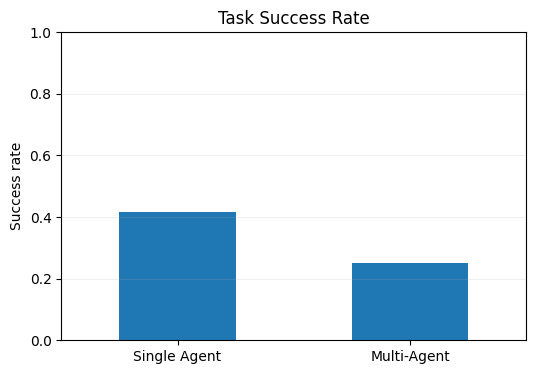

In [29]:
import matplotlib.pyplot as plt

task_success = pd.Series({
    "Single Agent":
        benchmark_results[
            "single_success"
        ].mean(),

    "Multi-Agent":
        benchmark_results[
            "multi_success"
        ].mean(),
})

display(
    task_success
    .to_frame(
        "Task Success Rate"
    )
    .round(4)
)

plt.figure(figsize=(6, 4))

task_success.plot(
    kind="bar"
)

plt.title(
    "Task Success Rate"
)
plt.ylabel("Success rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(
    axis="y",
    alpha=0.2,
)
plt.show()


## 28. Routing e delegation


In [30]:
routing_summary = pd.Series({
    "Specialist Coverage":
        benchmark_results[
            "specialist_coverage"
        ].mean(),

    "Exact Specialist Match":
        benchmark_results[
            "exact_specialist_match"
        ].mean(),

    "Avg Handoffs":
        benchmark_results[
            "handoffs"
        ].mean(),

    "Total Redundant Delegations":
        benchmark_results[
            "redundant_delegations"
        ].sum(),

    "Total Missing Delegations":
        benchmark_results[
            "missing_delegations"
        ].sum(),
})

display(
    routing_summary
    .to_frame(
        "Resultado"
    )
    .round(4)
)


,Resultado
Specialist Coverage,0.5833
Exact Specialist Match,0.5833
Avg Handoffs,1.2500
Total Redundant Delegations,0.0000
Total Missing Delegations,7.0000


## 29. Complexidade da tarefa vs desempenho

As tarefas são agrupadas pelo número de especialistas necessários.


In [31]:
benchmark_results[
    "required_specialist_count"
] = (
    benchmark_results[
        "required_specialists"
    ].apply(len)
)

complexity_summary = (
    benchmark_results
    .groupby(
        "required_specialist_count"
    )[
        [
            "single_success",
            "multi_success",
            "specialist_coverage",
            "exact_specialist_match",
            "single_latency_s",
            "multi_latency_s",
        ]
    ]
    .mean()
)

display(
    complexity_summary.round(4)
)


,single_success,multi_success,specialist_coverage,exact_specialist_match,single_latency_s,multi_latency_s
required_specialist_count,,,,,,
0,1.0000,1.0000,1.0000,1.0000,2.7459,2.5007
1,0.6667,0.3333,1.0000,1.0000,8.4011,10.6022
2,0.4000,0.2000,0.4000,0.4000,11.3581,16.7487
3,0.0000,0.0000,0.3333,0.3333,6.2509,26.5329


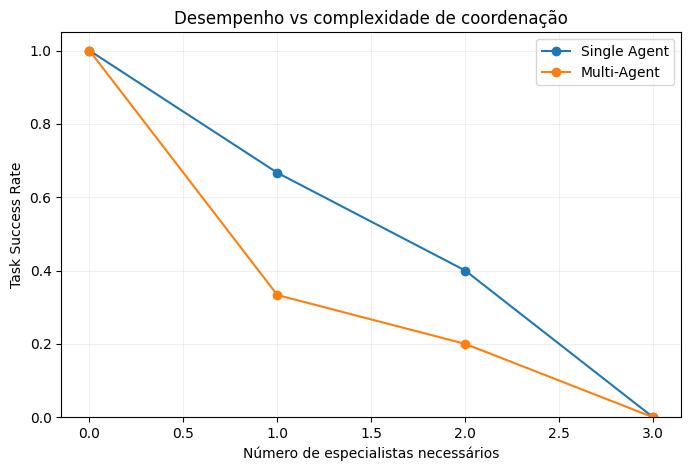

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    complexity_summary.index,
    complexity_summary[
        "single_success"
    ],
    marker="o",
    label="Single Agent",
)

plt.plot(
    complexity_summary.index,
    complexity_summary[
        "multi_success"
    ],
    marker="o",
    label="Multi-Agent",
)

plt.xlabel(
    "Número de especialistas necessários"
)
plt.ylabel(
    "Task Success Rate"
)
plt.title(
    "Desempenho vs complexidade de coordenação"
)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 30. Model calls e overhead de coordenação

Multi-agent pode realizar:

- inferências do supervisor;
- inferências do especialista;
- múltiplos handoffs.

O número de model calls é uma aproximação direta do custo de coordenação.


In [33]:
model_call_summary = pd.Series({
    "Single Agent":
        benchmark_results[
            "single_model_calls"
        ].mean(),

    "Multi-Agent":
        benchmark_results[
            "multi_model_calls"
        ].mean(),
})

display(
    model_call_summary
    .to_frame(
        "Model calls médios"
    )
    .round(3)
)

coordination_overhead_calls = (
    benchmark_results[
        "multi_model_calls"
    ].mean()
    -
    benchmark_results[
        "single_model_calls"
    ].mean()
)

print(
    "Overhead médio de model calls:",
    round(
        coordination_overhead_calls,
        3,
    ),
)


,Model calls médios
Single Agent,1.667
Multi-Agent,4.083


Overhead médio de model calls: 2.417


## 31. Latência


,Latência média (s)
Single Agent,8.624
Multi-Agent,16.471


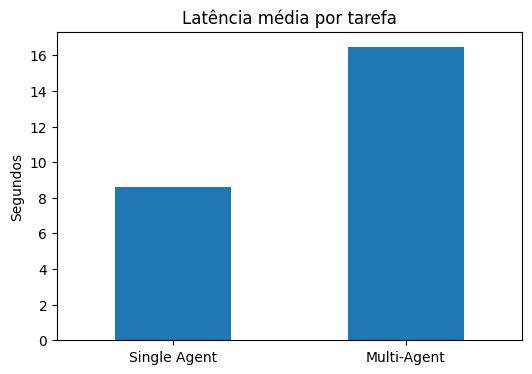

In [34]:
latency_summary = pd.Series({
    "Single Agent":
        benchmark_results[
            "single_latency_s"
        ].mean(),

    "Multi-Agent":
        benchmark_results[
            "multi_latency_s"
        ].mean(),
})

display(
    latency_summary
    .to_frame(
        "Latência média (s)"
    )
    .round(3)
)

plt.figure(figsize=(6, 4))

latency_summary.plot(
    kind="bar"
)

plt.title(
    "Latência média por tarefa"
)
plt.ylabel("Segundos")
plt.xticks(rotation=0)
plt.show()


## 32. Tool errors


In [35]:
tool_error_summary = pd.Series({
    "Single Agent":
        benchmark_results[
            "single_tool_errors"
        ].sum(),

    "Multi-Agent":
        benchmark_results[
            "multi_tool_errors"
        ].sum(),
})

display(
    tool_error_summary
    .to_frame(
        "Total de tool errors"
    )
)


,Total de tool errors
Single Agent,0
Multi-Agent,0


## 33. Delegações redundantes

Uma arquitetura multi-agent eficiente deve evitar chamar especialistas que não contribuem para a tarefa.


In [36]:
redundant_cases = (
    benchmark_results[
        benchmark_results[
            "redundant_delegations"
        ] > 0
    ]
)

if redundant_cases.empty:
    print(
        "Nenhuma delegação redundante "
        "foi observada."
    )
else:
    display(
        redundant_cases[
            [
                "id",
                "request",
                "required_specialists",
                "specialists_called",
                "redundant_delegations",
                "multi_success",
            ]
        ]
    )


Nenhuma delegação redundante foi observada.


## 34. Casos em que as arquiteturas discordam

Esta tabela é especialmente importante.

Ela identifica tarefas em que:

- single-agent acerta e multi-agent erra;
- multi-agent acerta e single-agent erra.


In [37]:
disagreement_mask = (
    benchmark_results["single_success"]
    != benchmark_results["multi_success"]
)

disagreements = benchmark_results[
    disagreement_mask
]

if disagreements.empty:
    print(
        "As duas arquiteturas tiveram "
        "o mesmo resultado em todas as tarefas."
    )
else:
    display(
        disagreements[
            [
                "id",
                "request",
                "single_success",
                "multi_success",
                "single_answer",
                "multi_answer",
                "specialists_called",
            ]
        ]
    )


,id,request,single_success,multi_success,single_answer,multi_answer,specialists_called
0,M01,Which warehouse stores SKU C300?,1,0,The warehouse that stores SKU C300 is North. T...,"To locate the storage for SKU C300, I need the...",[inventory]
4,M05,"For 3 units of SKU C300, give the catalog tota...",1,0,The catalog total price for 3 units of SKU C30...,To provide the total catalog price and total s...,"[pricing, logistics]"


## 35. Inspeção de uma coordenação complexa

Selecionamos automaticamente a tarefa com maior número de handoffs.


In [38]:
inspection_row = (
    benchmark_results
    .sort_values(
        by=[
            "handoffs",
            "multi_model_calls",
        ],
        ascending=False,
    )
    .iloc[0]
)

print(
    "TASK:",
    inspection_row[
        "id"
    ],
)

print(
    "\nREQUEST:"
)
print(
    inspection_row[
        "request"
    ]
)

print(
    "\nSPECIALISTS REQUIRED:"
)
print(
    inspection_row[
        "required_specialists"
    ]
)

print(
    "\nSPECIALISTS CALLED:"
)
print(
    inspection_row[
        "specialists_called"
    ]
)

print(
    "\nFINAL ANSWER:"
)
print(
    inspection_row[
        "multi_answer"
    ]
)

print(
    "\nDELEGATION DETAILS:"
)

display(
    pd.DataFrame(
        inspection_row[
            "delegation_details"
        ]
    )
)


TASK: M08

REQUEST:
For 8 units of SKU E500, give current stock, catalog total, total shipment weight in kilograms, and shipping cost to zone_1.

SPECIALISTS REQUIRED:
['inventory', 'pricing', 'logistics']

SPECIALISTS CALLED:
['inventory', 'pricing', 'logistics']

FINAL ANSWER:
To accurately calculate the total shipment weight for 8 units of SKU E500 to zone_1, I need to first get the weight of one unit of E500. Please wait while I gather the necessary information.

Once I have the weight of one unit, I will multiply it by 8 to find the total shipment weight.

DELEGATION DETAILS:


,specialist,answer,trajectory,steps,tool_calls,tool_errors,model_calls,latency_s,stop_reason
0,inventory,The current stock for SKU E500 is 9 units. It ...,"[{'step': 1, 'type': 'tool_call', 'tool': 'get...",2,[get_inventory_record],0,2,4.621942,final_answer
1,pricing,The catalog unit price for SKU E500 is $89.00....,"[{'step': 1, 'type': 'tool_call', 'tool': 'get...",2,[get_product_price],0,2,6.665531,final_answer
2,logistics,To determine the total shipment weight for 8 u...,"[{'step': 1, 'type': 'final_answer', 'content'...",1,[],0,1,4.974107,final_answer


## 36. Eficiência de delegação

Definimos uma métrica simples:

```text
delegation efficiency =
required specialist count / observed handoffs
```

com limite máximo igual a 1.

Para tarefas sem especialista:

- eficiência = 1 se não houver handoff;
- eficiência = 0 se houver delegação desnecessária.

Assim como no Study 011, essa é apenas uma aproximação.


In [39]:
def delegation_efficiency(
    row,
):
    required = row[
        "required_specialist_count"
    ]

    observed = row[
        "handoffs"
    ]

    if required == 0:
        return (
            1.0
            if observed == 0
            else 0.0
        )

    if observed == 0:
        return 0.0

    return min(
        required / observed,
        1.0,
    )


benchmark_results[
    "delegation_efficiency"
] = (
    benchmark_results.apply(
        delegation_efficiency,
        axis=1,
    )
)

display(
    benchmark_results[
        [
            "id",
            "required_specialist_count",
            "handoffs",
            "delegation_efficiency",
            "multi_success",
        ]
    ]
)

print(
    "Eficiência média de delegação:",
    round(
        benchmark_results[
            "delegation_efficiency"
        ].mean(),
        3,
    ),
)


,id,required_specialist_count,handoffs,delegation_efficiency,multi_success
0,M01,1,1,1.0,0
1,M02,1,1,1.0,1
2,M03,1,1,1.0,0
3,M04,2,1,1.0,0
4,M05,2,2,1.0,0
5,M06,2,0,0.0,0
6,M07,3,1,1.0,0
7,M08,3,3,1.0,0
8,M09,2,1,1.0,0
9,M10,0,0,1.0,1


Eficiência média de delegação: 0.917


## 37. Comparação end-to-end


In [40]:
end_to_end_summary = pd.DataFrame({
    "Single Agent": {
        "Task Success":
            benchmark_results[
                "single_success"
            ].mean(),

        "Avg Model Calls":
            benchmark_results[
                "single_model_calls"
            ].mean(),

        "Avg Latency s":
            benchmark_results[
                "single_latency_s"
            ].mean(),

        "Tool Errors":
            benchmark_results[
                "single_tool_errors"
            ].sum(),
    },

    "Multi-Agent": {
        "Task Success":
            benchmark_results[
                "multi_success"
            ].mean(),

        "Avg Model Calls":
            benchmark_results[
                "multi_model_calls"
            ].mean(),

        "Avg Latency s":
            benchmark_results[
                "multi_latency_s"
            ].mean(),

        "Tool Errors":
            benchmark_results[
                "multi_tool_errors"
            ].sum(),
    },
}).T

display(
    end_to_end_summary.round(4)
)


,Task Success,Avg Model Calls,Avg Latency s,Tool Errors
Single Agent,0.4167,1.6667,8.6244,0.0
Multi-Agent,0.2500,4.0833,16.4708,0.0


## 38. Conclusão

A conclusão abaixo utiliza os resultados reais da execução.


In [41]:
from IPython.display import Markdown, display

single_success = (
    benchmark_results[
        "single_success"
    ].mean()
)

multi_success = (
    benchmark_results[
        "multi_success"
    ].mean()
)

specialist_coverage = (
    benchmark_results[
        "specialist_coverage"
    ].mean()
)

exact_specialist_match = (
    benchmark_results[
        "exact_specialist_match"
    ].mean()
)

delegation_efficiency_mean = (
    benchmark_results[
        "delegation_efficiency"
    ].mean()
)

single_calls = (
    benchmark_results[
        "single_model_calls"
    ].mean()
)

multi_calls = (
    benchmark_results[
        "multi_model_calls"
    ].mean()
)

single_latency = (
    benchmark_results[
        "single_latency_s"
    ].mean()
)

multi_latency = (
    benchmark_results[
        "multi_latency_s"
    ].mean()
)

success_difference = (
    multi_success
    - single_success
)

call_overhead = (
    multi_calls
    - single_calls
)

latency_multiplier = (
    multi_latency
    / single_latency
    if single_latency > 0
    else np.nan
)

conclusion = f'''
### Síntese dos resultados

#### Task Success

- **Single Agent:** {single_success:.3f}
- **Multi-Agent:** {multi_success:.3f}
- **Diferença Multi − Single:** {success_difference:+.3f}

#### Routing

- **Specialist Coverage:** {specialist_coverage:.3f}
- **Exact Specialist Match:** {exact_specialist_match:.3f}
- **Delegation Efficiency:** {delegation_efficiency_mean:.3f}

#### Coordenação

- **Model calls — Single Agent:** {single_calls:.2f}
- **Model calls — Multi-Agent:** {multi_calls:.2f}
- **Overhead médio de model calls:** {call_overhead:+.2f}

#### Latência

- **Single Agent:** {single_latency:.2f} s
- **Multi-Agent:** {multi_latency:.2f} s
- **Multiplicador de latência:** {latency_multiplier:.2f}x

### Interpretação

A arquitetura multi-agent troca simplicidade por decomposição.

O single-agent possui:

- menos handoffs;
- menos inferências;
- menor overhead de coordenação;
- acesso a um espaço maior de ferramentas.

O sistema multi-agent possui:

- ferramentas segmentadas por domínio;
- responsabilidades explícitas;
- possibilidade de isolar permissões;
- melhor rastreabilidade de quem produziu cada parte da resposta.

### Especialização não garante superioridade

Se Multi-Agent não superar Single Agent em Task Success, isso não significa necessariamente que a arquitetura seja inútil.

Ela pode oferecer benefícios que este benchmark mede apenas parcialmente:

- isolamento de permissões;
- separação de responsabilidades;
- auditabilidade;
- desenvolvimento independente de especialistas;
- prompts específicos por domínio.

Por outro lado, se esses benefícios não forem necessários, a coordenação pode ser apenas custo adicional.

### Routing é parte do problema

Em sistemas multi-agent, existe uma nova classe de erro:

> **o supervisor pode delegar a tarefa correta ao agente errado.**

Portanto, além de avaliar respostas e tool calls, precisamos avaliar:

**user request → routing → specialist → tools → report → synthesis**

### Coordination overhead

Cada handoff pode adicionar:

- uma chamada ao supervisor;
- chamadas internas do especialista;
- serialização de contexto;
- latência;
- oportunidade de erro.

Essa é uma razão importante para evitar arquiteturas multi-agent apenas por estética.

### Segurança e permissões

Uma vantagem arquitetural real da especialização é que cada agente pode possuir **um conjunto mínimo de ferramentas**.

Neste notebook:

- Inventory Agent não acessa preço;
- Pricing Agent não acessa estoque;
- Logistics Agent não acessa reorder point.

Em sistemas reais, isso pode ser transformado em:

- credenciais diferentes;
- escopos distintos;
- políticas de autorização;
- ambientes separados.

### Limitações

- apenas três especialistas;
- ambiente pequeno e determinístico;
- mesmo LLM em todos os papéis;
- apenas 12 tarefas;
- ausência de comunicação direta entre especialistas;
- estado compartilhado ocorre via supervisor;
- não há execução paralela;
- não há memória persistente;
- não há ferramentas externas reais;
- custo monetário não foi calculado;
- não há tarefas long-running;
- não há conflitos entre especialistas.

### Quando usar Single Agent

Uma arquitetura simples tende a ser preferível quando:

- poucas ferramentas existem;
- permissões são semelhantes;
- tarefas são curtas;
- dependências entre domínios são pequenas;
- latência importa bastante.

### Quando Multi-Agent pode fazer sentido

A especialização ganha justificativa quando:

- existem muitos domínios;
- ferramentas e permissões diferem;
- equipes mantêm componentes separados;
- tarefas exigem decomposição real;
- auditoria por responsabilidade é importante;
- especialistas precisam de prompts/modelos/contextos diferentes.

### Próximo estudo — Study 013: Serving & Monitoring

Até aqui avaliamos modelos e sistemas dentro de notebooks.

O próximo passo será perguntar:

> **Como transformar um sistema de IA em um serviço observável e operável?**

O Study 013 deverá introduzir:

- API de inferência;
- schemas de request/response;
- health checks;
- containerização;
- logging estruturado;
- métricas;
- latência;
- erros;
- tracing;
- monitoramento;
- drift;
- alertas;
- testes de carga;
- versionamento do modelo.
'''

display(
    Markdown(conclusion)
)



### Síntese dos resultados

#### Task Success

- **Single Agent:** 0.417
- **Multi-Agent:** 0.250
- **Diferença Multi − Single:** -0.167

#### Routing

- **Specialist Coverage:** 0.583
- **Exact Specialist Match:** 0.583
- **Delegation Efficiency:** 0.917

#### Coordenação

- **Model calls — Single Agent:** 1.67
- **Model calls — Multi-Agent:** 4.08
- **Overhead médio de model calls:** +2.42

#### Latência

- **Single Agent:** 8.62 s
- **Multi-Agent:** 16.47 s
- **Multiplicador de latência:** 1.91x

### Interpretação

A arquitetura multi-agent troca simplicidade por decomposição.

O single-agent possui:

- menos handoffs;
- menos inferências;
- menor overhead de coordenação;
- acesso a um espaço maior de ferramentas.

O sistema multi-agent possui:

- ferramentas segmentadas por domínio;
- responsabilidades explícitas;
- possibilidade de isolar permissões;
- melhor rastreabilidade de quem produziu cada parte da resposta.

### Especialização não garante superioridade

Se Multi-Agent não superar Single Agent em Task Success, isso não significa necessariamente que a arquitetura seja inútil.

Ela pode oferecer benefícios que este benchmark mede apenas parcialmente:

- isolamento de permissões;
- separação de responsabilidades;
- auditabilidade;
- desenvolvimento independente de especialistas;
- prompts específicos por domínio.

Por outro lado, se esses benefícios não forem necessários, a coordenação pode ser apenas custo adicional.

### Routing é parte do problema

Em sistemas multi-agent, existe uma nova classe de erro:

> **o supervisor pode delegar a tarefa correta ao agente errado.**

Portanto, além de avaliar respostas e tool calls, precisamos avaliar:

**user request → routing → specialist → tools → report → synthesis**

### Coordination overhead

Cada handoff pode adicionar:

- uma chamada ao supervisor;
- chamadas internas do especialista;
- serialização de contexto;
- latência;
- oportunidade de erro.

Essa é uma razão importante para evitar arquiteturas multi-agent apenas por estética.

### Segurança e permissões

Uma vantagem arquitetural real da especialização é que cada agente pode possuir **um conjunto mínimo de ferramentas**.

Neste notebook:

- Inventory Agent não acessa preço;
- Pricing Agent não acessa estoque;
- Logistics Agent não acessa reorder point.

Em sistemas reais, isso pode ser transformado em:

- credenciais diferentes;
- escopos distintos;
- políticas de autorização;
- ambientes separados.

### Limitações

- apenas três especialistas;
- ambiente pequeno e determinístico;
- mesmo LLM em todos os papéis;
- apenas 12 tarefas;
- ausência de comunicação direta entre especialistas;
- estado compartilhado ocorre via supervisor;
- não há execução paralela;
- não há memória persistente;
- não há ferramentas externas reais;
- custo monetário não foi calculado;
- não há tarefas long-running;
- não há conflitos entre especialistas.

### Quando usar Single Agent

Uma arquitetura simples tende a ser preferível quando:

- poucas ferramentas existem;
- permissões são semelhantes;
- tarefas são curtas;
- dependências entre domínios são pequenas;
- latência importa bastante.

### Quando Multi-Agent pode fazer sentido

A especialização ganha justificativa quando:

- existem muitos domínios;
- ferramentas e permissões diferem;
- equipes mantêm componentes separados;
- tarefas exigem decomposição real;
- auditoria por responsabilidade é importante;
- especialistas precisam de prompts/modelos/contextos diferentes.

### Próximo estudo — Study 013: Serving & Monitoring

Até aqui avaliamos modelos e sistemas dentro de notebooks.

O próximo passo será perguntar:

> **Como transformar um sistema de IA em um serviço observável e operável?**

O Study 013 deverá introduzir:

- API de inferência;
- schemas de request/response;
- health checks;
- containerização;
- logging estruturado;
- métricas;
- latência;
- erros;
- tracing;
- monitoramento;
- drift;
- alertas;
- testes de carga;
- versionamento do modelo.


## 39. Principais aprendizados

### 1. Multi-agent cria um novo problema: routing

Antes de executar ferramentas, o supervisor precisa decidir **quem** deve resolver cada parte.

### 2. Especialização permite menor privilégio

Cada agente pode receber apenas ferramentas e dados do próprio domínio.

### 3. Handoffs custam

Cada delegação adiciona comunicação e inferência.

### 4. Mais agentes não significam mais inteligência

Uma decomposição ruim pode ser inferior a um único agente bem projetado.

### 5. Métricas precisam incluir coordenação

Task Success isolado não mostra:

- roteamento incorreto;
- delegação redundante;
- handoffs;
- model calls;
- latência.

### 6. Arquitetura deve seguir o problema

Single-agent e multi-agent são escolhas de engenharia, não níveis obrigatórios de maturidade.


## Referências

- Hugging Face Transformers — Tool Use;
- Hugging Face Transformers — Chat Templates;
- Hermes 2 Pro Llama 3;
- padrões supervisor / specialist para sistemas multi-agent.

### Reprodutibilidade

Para publicação definitiva:

1. execute tudo em um único runtime;
2. preserve outputs;
3. registre GPU;
4. registre versão do Transformers;
5. mantenha o benchmark congelado;
6. não modifique prompts depois de observar resultados sem registrar uma nova versão do experimento.
